<a id="sec-title"></a>

# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** [Sijie Yang](https://sijie-yang.com), [Zdravko Trivic](https://cde.nus.edu.sg/arch/staffs/zdravko-trivic-dr/), [Yihan Zhu](https://ual.sg/author/yihan-zhu/), [Mahmoud Abdelrahman](https://ual.sg/author/mahmoud-abdelrahman/), [Filip Biljecki](https://filipbiljecki.com)*

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

**All notebooks in this project (code series):**

- <a href="code_0_social_media_post_embedding.ipynb" target="_blank" rel="noopener noreferrer">code_0 — social media post embedding</a>
- <a href="code_1_social_activity_data.ipynb" target="_blank" rel="noopener noreferrer">code_1 — social activity data</a>
- <a href="code_2_geospatial_data.ipynb" target="_blank" rel="noopener noreferrer">code_2 — geospatial data</a>
- <a href="code_3_uci_social_activity_field.ipynb" target="_blank" rel="noopener noreferrer">code_3 — UCI social activity field</a>
- <a href="code_4_uci_causal_forest.ipynb" target="_blank" rel="noopener noreferrer">code_4 — UCI causal forest</a>
- <a href="code_5_uci_resident_expert_survey.ipynb" target="_blank" rel="noopener noreferrer">code_5 — resident & expert survey for UCI modelling</a>
- <a href="code_6_uci_modelling.ipynb" target="_blank" rel="noopener noreferrer">code_6 — UCI modelling</a>
- <a href="code_7_uci_optimisation_puci.ipynb" target="_blank" rel="noopener noreferrer">code_7 — UCI optimisation (pUCI & UCP)</a>
- <a href="code_8_result_analytics.ipynb" target="_blank" rel="noopener noreferrer">code_8 — result analytics</a>

**Abbreviations used in this codebase series:**  
- Comfort metrics: `UCI` (Urban Comfort Index), `UCP` (Urban Comfort Potential), `pUCI` (policy-driven Urban Comfort Index).  
- Variation metrics: `SSV` (Social-Spatial Variation), `SVI` (Social Variation Index), `SPVI` (Spatial Variation Index), `SSVI` (Socio-Spatial Variation Index).  
- Geospatial dimensions: `SP` (Streetscape Perception), `FC` (Functionality), `AC` (Accessibility), `CD` (Contact Density).
- Model and dimensions: `HGWR` (Hierarchical Geographically Weighted Regression), `CATE` (Conditional Average Treatment Effect).


<a id="sec-overview"></a>


<a id="sec-1-definition"></a>

## 1 Activity comfort field definition

At grid/location $\mathbf{u}$ for activity category $i$, **social activity comfort** combines posting intensity and category comfort sentiment (see `code_1_social_activity_data`):

$$
\text{SocialActivityComfort}_{i,\mathbf{u}} = \text{SocialActivityIntensity}_{i,\mathbf{u}} \times \text{ActivityComfortSentiment}_{i,\mathbf{u}}.
$$

These values are stored in `social_activity_comfort_*` columns. Grid-level comfort can still be uneven, so we model neighborhood diffusion and spillover by defining an **Activity Comfort Field**:

$$
\widetilde{\text{ActivityComfortField}}_{i,\mathbf{u}} = \sum_{\mathbf{v} \in \mathcal{U}} K_\sigma\!\left(d(\mathbf{u},\mathbf{v})\right)\,\text{SocialActivityComfort}_{i,\mathbf{v}}
$$

where $K_\sigma(\cdot)$ is a Gaussian kernel and $d(\mathbf{u},\mathbf{v})$ is spatial distance. The kernel is:

$$
K_\sigma(r)=\frac{1}{\sqrt{2\pi}\sigma}\exp\!\left(-\frac{r^2}{2\sigma^2}\right),\quad r=d(\mathbf{u},\mathbf{v}).
$$

This implies that nearby grids (small $r$) receive larger weights, while distant grids decay exponentially in influence.

We then align the smoothed field back to the original **social activity comfort** distribution scale and enforce non-negativity:

$$
\text{ActivityComfortField}_{i,\mathbf{u}} = \max\left(0,\;\frac{\widetilde{\text{ActivityComfortField}}_{i,\mathbf{u}}-\mu_{\widetilde{i}}}{\sigma_{\widetilde{i}}+\varepsilon}\sigma_i+\mu_i\right).
$$

Here, $\mu_i,\sigma_i$ are the mean and standard deviation of the raw social activity comfort distribution for category $i$, $\mu_{\widetilde{i}},\sigma_{\widetilde{i}}$ are the corresponding statistics after field smoothing, and $\varepsilon$ is a numerical stability term.

Parameter settings used in this study (consistent with code):
- `grid_base = 500`: **calibrated to the native Singapore grid cell size**, not an arbitrary constant. Social and geospatial inputs live on a shared lattice of **2,096 occupied cells** on a regular **~0.005° (~550 m)** spacing (85 longitude × 49 latitude bins over the study bbox; see `code_2` / `data_grid_point_coordinates.csv`). `fx_gaussian_grid_smooth` builds a **finer implicit raster** over the same bbox: with `grid_base = 500` the long edge is ~500 interpolation pixels, so each native grid cell spans **~6 raster pixels** along the long axis ($500/85 \approx 5.9$). That keeps the Gaussian kernel defined at sub-cell resolution relative to the observation pixels. The algorithm adaptively sets `(x_grid_size, y_grid_size)` from the longitude–latitude aspect ratio to preserve spatial shape.
- `sigma = 5.0`: Gaussian kernel standard deviation in **interpolation-raster cell units** (not degrees). At this calibration, `sigma = 5` is ~5 sub-cell widths; together with `grid_base = 500` it defines the physical smoothing scale used downstream. Larger $\sigma$ yields stronger spatial diffusion; smaller $\sigma$ preserves sharper local peaks. **§2 selects `sigma` by Pareto analysis; `grid_base` is fixed at this native-calibrated value.**

Why this transformation is used:
- reduce sparsity and local noise in comfort signals;
- preserve neighborhood influence so the metric behaves as a spatial **activity comfort field** rather than isolated grid values;
- provide a more stable and interpretable exposure variable for downstream causal analysis.


<a id="sec-1-1-config"></a>

### 1.1 Paths and activity keys

Import libraries and set paths to the social-activity and geospatial GPKGs, activity short keys (`FX_ACT_KEYS`), and the corresponding `social_activity_comfort_*` column names used as smoothing inputs.


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.preprocessing import StandardScaler

# -------------------------
# Config
# -------------------------
FX_SOCIAL_FILE_PATH = "data/data_social_activity.gpkg"
FX_GEOSPATIAL_FILE_PATH = "data/data_geospatial.gpkg"
# Short category keys (field outputs: "{key}_field" — matches code_4 / code_6 ACT_COLUMNS)
FX_ACT_KEYS = ["eating", "nature", "community", "walking", "sightseeing"]
# Full column names as stored in data_social_activity.gpkg (inputs to smoothing)
FX_COMFORT_SOURCE_COLS = [f"social_activity_comfort_{k}" for k in FX_ACT_KEYS]
# Sensitivity / regression use raw comfort columns (full names)
FX_ACT_COLUMNS = FX_COMFORT_SOURCE_COLS
FX_DIMENSION_FEATURES = {
    "SP": ["SP_1-E_comfort", "SP_2-E_sunshine_intensity", "SP_3-E_temp_inference", "SP_4-E_humidity_inference", "SP_5-E_wind_inference", "SP_6-E_greenery_rate", "SP_7-E_shading_area", "SP_8-E_heat_source", "SP_9-E_traffic_flow", "SP_1-D_imageability", "SP_2-D_enclosure", "SP_3-D_human_scale", "SP_4-D_complexity"],
    "FC": ["FC_1-R_eating_rating", "FC_1-D_eating_density", "FC_2-R_retail_rating", "FC_2-D_retail_density", "FC_3-R_life_rating", "FC_3-D_life_density", "FC_4-R_recreation_rating", "FC_4-D_recreation_density", "FC_5-R_health_rating", "FC_5-D_health_density", "FC_6-R_community_rating", "FC_6-D_community_density", "FC_7-R_trans_rating", "FC_7-D_trans_density", "FC_1-H_HDB_density", "FC_1-G_review_polarity", "FC_2-G_review_subjectivity"],
    "AC": ["AC_1-L_closeness400", "AC_2-L_closeness800", "AC_1-G_closeness2000", "AC_2-G_closeness6000", "AC_1-T_subway_accessibility", "AC_2-T_subway_density", "AC_3-T_bus_accessibility", "AC_4-T_bus_density"],
    "CD": ["CD_1-P_population", "CD_1-B_building_density", "CD_1-L_leisure_density"],
}

# Baseline values used in code.ipynb
FX_BASE_GRID_BASE = 500
FX_BASE_SIGMA = 5.0


<a id="sec-1-2-core"></a>

### 1.2 Gaussian field core

`fx_gaussian_grid_smooth` builds a longitude–latitude grid (adaptive `x_grid_size` / `y_grid_size` from `grid_base`), applies a Gaussian kernel in grid-cell units (`sigma`), and re-scales the smoothed surface to match the raw social activity comfort mean and standard deviation (non-negative clip).


In [2]:
# -------------------------
# Core activity comfort field function (Gaussian smooth; aligned with original implementation)
# -------------------------
def fx_gaussian_grid_smooth(temp_df, target_col, grid_base=500, sigma=5.0):
    x_min, x_max = temp_df["longitude"].min(), temp_df["longitude"].max()
    y_min, y_max = temp_df["latitude"].min(), temp_df["latitude"].max()

    x_range = x_max - x_min
    y_range = y_max - y_min
    if x_range == 0 or y_range == 0:
        return temp_df[target_col].values.astype(float)

    aspect_ratio = x_range / y_range
    if aspect_ratio > 1:
        x_grid_size = int(grid_base)
        y_grid_size = max(2, int(grid_base / aspect_ratio))
    else:
        y_grid_size = int(grid_base)
        x_grid_size = max(2, int(grid_base * aspect_ratio))

    x_grid = np.linspace(x_min, x_max, x_grid_size)
    y_grid = np.linspace(y_min, y_max, y_grid_size)
    grid = np.zeros((y_grid_size, x_grid_size), dtype=float)

    for _, row in temp_df.iterrows():
        x_idx = int((row["longitude"] - x_min) / x_range * (x_grid_size - 1))
        y_idx = int((row["latitude"] - y_min) / y_range * (y_grid_size - 1))
        grid[y_idx, x_idx] += row[target_col]

    smoothed_grid = ndimage.gaussian_filter(grid, sigma=sigma)

    smoothed_values = []
    for _, row in temp_df.iterrows():
        x_idx = int((row["longitude"] - x_min) / x_range * (x_grid_size - 1))
        y_idx = int((row["latitude"] - y_min) / y_range * (y_grid_size - 1))
        smoothed_values.append(smoothed_grid[y_idx, x_idx])

    smoothed_values = np.asarray(smoothed_values, dtype=float)

    # Match raw distribution (mean/std)
    raw = temp_df[target_col].values.astype(float)
    raw_mean, raw_std = np.mean(raw), np.std(raw)
    sm_mean, sm_std = np.mean(smoothed_values), np.std(smoothed_values)

    if sm_std > 0:
        normalized = ((smoothed_values - sm_mean) / sm_std) * raw_std + raw_mean
    else:
        normalized = np.full_like(smoothed_values, fill_value=raw_mean)

    # Enforce nonnegative
    min_val = np.min(normalized)
    if min_val < 0:
        normalized = normalized - min_val

    return normalized


<a id="sec-1-3-load"></a>

### 1.3 Load inputs and baseline fields

Load both GPKGs on EPSG:4326, merge on `id`, compute baseline `{key}_field` columns at default `grid_base=500`, `sigma=5.0`, and prepare `fx_available_features` for regression in §2.


In [3]:
# -------------------------
# Data load + baseline extraction (activity comfort field + original features)
# -------------------------
fx_social_gdf = gpd.read_file(FX_SOCIAL_FILE_PATH)
fx_geo_gdf = gpd.read_file(FX_GEOSPATIAL_FILE_PATH)

for _gdf in [fx_social_gdf, fx_geo_gdf]:
    if _gdf.crs is None:
        _gdf.set_crs("EPSG:4326", inplace=True)
    elif _gdf.crs.to_string() != "EPSG:4326":
        _gdf.to_crs("EPSG:4326", inplace=True)

if "longitude" in fx_geo_gdf.columns and "latitude" in fx_geo_gdf.columns:
    fx_geo_gdf["longitude"] = fx_geo_gdf["longitude"].astype(float)
    fx_geo_gdf["latitude"] = fx_geo_gdf["latitude"].astype(float)
else:
    fx_geo_gdf["longitude"] = fx_geo_gdf.geometry.x.astype(float)
    fx_geo_gdf["latitude"] = fx_geo_gdf.geometry.y.astype(float)

social_cols = ["id"] + [c for c in FX_COMFORT_SOURCE_COLS if c in fx_social_gdf.columns]
missing_acts = [c for c in FX_COMFORT_SOURCE_COLS if c not in social_cols]
if missing_acts:
    raise RuntimeError(f"Missing social activity comfort columns in source: {missing_acts}")

fx_gdf = fx_geo_gdf.merge(fx_social_gdf[social_cols], on="id", how="inner")

fx_expected_features = sum(FX_DIMENSION_FEATURES.values(), [])
fx_available_features = [c for c in fx_expected_features if c in fx_gdf.columns]

# Build activity comfort field variables: read social_activity_comfort_* , write "{key}_field"
for key, src in zip(FX_ACT_KEYS, FX_COMFORT_SOURCE_COLS):
    temp_df = (
        fx_gdf[["longitude", "latitude", src]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["longitude", "latitude", src])
        .copy()
    )
    fx_gdf.loc[temp_df.index, f"{key}_field"] = fx_gaussian_grid_smooth(
        temp_df,
        src,
        grid_base=FX_BASE_GRID_BASE,
        sigma=FX_BASE_SIGMA,
    )

fx_use_cols = (
    FX_COMFORT_SOURCE_COLS
    + fx_available_features
    + ["longitude", "latitude"]
    + [f"{k}_field" for k in FX_ACT_KEYS]
)

fx_df = (
    fx_gdf[fx_use_cols + ["geometry"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=fx_use_cols + ["geometry"])
    .copy()
)
if fx_df.geometry.is_empty.any():
    fx_df = fx_df.loc[~fx_df.geometry.is_empty].copy()

fx_coords = np.column_stack([fx_df["longitude"].values, fx_df["latitude"].values])
fx_x_scaled_df = pd.DataFrame(
    StandardScaler().fit_transform(fx_df[fx_available_features].values),
    columns=fx_available_features,
    index=fx_df.index,
)

print(f"Social source: {FX_SOCIAL_FILE_PATH}")
print(f"Geospatial source: {FX_GEOSPATIAL_FILE_PATH}")
print(f"UCI modelling table ready: rows={len(fx_df)}, features={len(fx_available_features)}")
print(f"Baseline activity comfort field parameters: grid_base={FX_BASE_GRID_BASE}, sigma={FX_BASE_SIGMA}")


Social source: data/data_social_activity.gpkg
Geospatial source: data/data_geospatial.gpkg
UCI modelling table ready: rows=2096, features=41
Baseline activity comfort field parameters: grid_base=500, sigma=5.0


<a id="sec-2-params"></a>

## 2. Pareto-based smoothing bandwidth selection

**`grid_base = 500` is fixed a priori** from the native observation grid: the shared 2,096-cell Singapore lattice has ~0.005° (~550 m) spacing, and `grid_base = 500` makes the smoothing raster resolve each native cell into ~6 interpolation pixels along the long edge (§1). **§2 does not search over `grid_base`.** Only smoothing bandwidth `sigma` is chosen by a **two-objective Pareto analysis** at that raster calibration:

1. **Spatial fidelity** `F` — mean over activities of `(Pearson r + top-10% hotspot overlap) / 2` between raw social activity comfort and the smoothed field.
2. **Spatial predictive structure** `G` — mean **spatial block cross-validated** `R²` when linearly predicting the smoothed field from the 41 geospatial features (5 KMeans spatial blocks; no in-sample fit for selection).

We fine-sweep `sigma`, identify the non-dominated Pareto set in `(F, G)`, and select the **knee** (maximum perpendicular distance to the chord between frontier endpoints). An appendix grid documents matched effective bandwidth `grid_base / sigma` across raster resolutions.

**Subsections:**
- [2.1 Method boundaries and bias](#sec-2-1-bias)
- [2.2 Pareto objectives and knee rule](#sec-2-2-rule)
- [2.3 Helpers and spatial block CV](#sec-2-3-helpers)
- [2.4 Sigma sweep at grid_base = 500](#sec-2-4-sweep)
- [2.5 Pareto frontier plot](#sec-2-5-pareto)
- [2.6 Metrics vs sigma](#sec-2-6-focus)
- [2.7 Knee selection and robustness](#sec-2-7-recommend)


<a id="sec-2-1-bias"></a>

### 2.1 Method Boundaries and Bias Risks

- **Platform and population bias**: social-media activity does not represent all demographic groups equally, so the activity comfort field should be interpreted as a proxy of observed digital activity (via comfort-weighted signals) rather than complete social participation.
- **Temporal sampling bias**: posting behavior varies by time-of-day, weekday/weekend, and events. If data are temporally imbalanced, the resulting field may overstate certain periods.
- **Field-transformation trade-off in sparse areas**: stronger diffusion can improve stability but may blur local heterogeneity and create over-diffused hotspots in low-sample regions.

These limits do not invalidate the method, but they should be explicitly considered when comparing places or deriving planning recommendations.


<a id="sec-2-2-rule"></a>

### 2.2 Pareto objectives and knee rule

**Objectives (both maximised):**

| Symbol | Definition |
|--------|------------|
| `fidelity_mean` | Mean over five activities of `(pearson_corr + top10_overlap) / 2` |
| `cv_r2_mean` | Mean spatial block CV `R²` (41 features → smoothed field; 5 spatial blocks) |

**Selection (no weighted composite score, no ad-hoc triple threshold):**

1. Compute the non-dominated set in `(fidelity_mean, cv_r2_mean)` over the fine `sigma` grid at `grid_base = 500`.
2. **Field-relevant branch:** drop frontier points with `corr_mean > 0.95` (near-copy smoothing; CV `R²` ≈ 0.07, not a usable activity comfort field).
3. Sort the remaining frontier by decreasing `fidelity_mean` and take the **knee** (maximum perpendicular distance to the chord between frontier endpoints in normalised `(F, G)` space).
4. Recommended setting: `grid_base = 500`, `sigma = knee_sigma`.

`r2_insample_mean` is diagnostic only (not used for selection).


<a id="sec-2-3-helpers"></a>

### 2.3 Helpers and spatial block CV

Define the fine `sigma` grid at `grid_base = 500`, fidelity / hotspot helpers, spatial block assignment (KMeans on lon–lat), and spatial block CV `R²` for objective `G`.


In [17]:
# -------------------------
# 2A) Settings + helpers (Pareto objectives F and G)
# -------------------------
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

FOCUS_GRID_BASE = 500
SIGMA_CANDIDATES = [
    1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 8.0, 9.0, 10.0, 12.0,
]
# Appendix: effective bandwidth grid_base / sigma (multiple ratio bands)
EQUIV_BANDWIDTH_RATIOS = [60, 80, 100, 120, 140]
EQUIV_GRID_BASE_CANDIDATES = [300, 400, 500, 600, 700]
TOP_FRAC = 0.10
SPATIAL_CV_BLOCKS = 5
SPATIAL_CV_SPLITS = 5
FIELD_RELEVANT_MAX_CORR = 0.95


def _safe_corr(a, b):
    if len(a) < 2:
        return np.nan
    a_std = np.std(a)
    b_std = np.std(b)
    if a_std == 0 or b_std == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def _top_overlap_ratio(raw, ext, top_frac=0.10):
    n = len(raw)
    if n == 0:
        return np.nan
    k = max(1, int(np.ceil(n * top_frac)))
    raw_idx = np.argpartition(raw, -k)[-k:]
    ext_idx = np.argpartition(ext, -k)[-k:]
    overlap = len(set(raw_idx).intersection(set(ext_idx)))
    return overlap / k


def _spatial_block_groups(longitude, latitude, n_blocks=5, random_state=0):
    coords = np.column_stack([longitude.astype(float), latitude.astype(float)])
    n_blocks = int(min(n_blocks, len(coords)))
    if n_blocks < 2:
        return np.zeros(len(coords), dtype=int)
    km = KMeans(n_clusters=n_blocks, random_state=random_state, n_init=10)
    return km.fit_predict(coords)


def _spatial_block_cv_r2(X, y, groups, n_splits=5):
    unique_groups = np.unique(groups)
    if len(unique_groups) < 2 or len(y) < n_splits + 1:
        return np.nan
    n_splits = min(n_splits, len(unique_groups))
    gkf = GroupKFold(n_splits=n_splits)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression()),
    ])
    scores = []
    for train_idx, test_idx in gkf.split(X, y, groups):
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        scores.append(r2_score(y[test_idx], pred))
    return float(np.mean(scores))


def _build_xy_for_setting(gdf, activity, feature_cols, sigma, grid_base):
    cols = ["longitude", "latitude", activity] + feature_cols
    temp = (
        gdf[cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=cols)
        .copy()
    )
    if len(temp) < 3:
        return None, None, None

    y = fx_gaussian_grid_smooth(
        temp[["longitude", "latitude", activity]],
        activity,
        grid_base=grid_base,
        sigma=sigma,
    )
    groups = _spatial_block_groups(temp["longitude"].values, temp["latitude"].values, n_blocks=SPATIAL_CV_BLOCKS)
    X = temp[feature_cols].values.astype(float)
    return X, y, groups


def evaluate_one_setting(gdf, act_columns, sigma, grid_base):
    rows = []
    for act in act_columns:
        temp_df = (
            gdf[["longitude", "latitude", act]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["longitude", "latitude", act])
            .copy()
        )
        raw = temp_df[act].values.astype(float)
        ext = fx_gaussian_grid_smooth(temp_df, act, grid_base=grid_base, sigma=sigma)
        corr = _safe_corr(raw, ext)
        mae = float(np.mean(np.abs(ext - raw)))
        hotspot_overlap = _top_overlap_ratio(raw, ext, top_frac=TOP_FRAC)
        fidelity = (corr + hotspot_overlap) / 2.0 if np.isfinite(corr) and np.isfinite(hotspot_overlap) else np.nan
        rows.append({
            "activity": act,
            "sigma": sigma,
            "grid_base": grid_base,
            "pearson_corr": corr,
            "fidelity": fidelity,
            "mae": mae,
            "top10_overlap": hotspot_overlap,
        })
    return pd.DataFrame(rows)


def evaluate_regression_one_setting(gdf, act_columns, feature_cols, sigma, grid_base):
    rows = []
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression()),
    ])
    for act in act_columns:
        built = _build_xy_for_setting(gdf, act, feature_cols, sigma=sigma, grid_base=grid_base)
        if built[0] is None:
            rows.append({
                "activity": act,
                "sigma": sigma,
                "grid_base": grid_base,
                "cv_r2": np.nan,
                "r2_insample": np.nan,
                "rmse_insample": np.nan,
            })
            continue
        X, y, groups = built
        cv_r2 = _spatial_block_cv_r2(X, y, groups, n_splits=SPATIAL_CV_SPLITS)
        model.fit(X, y)
        pred = model.predict(X)
        rows.append({
            "activity": act,
            "sigma": sigma,
            "grid_base": grid_base,
            "cv_r2": cv_r2,
            "r2_insample": float(r2_score(y, pred)),
            "rmse_insample": float(np.sqrt(mean_squared_error(y, pred))),
        })
    return pd.DataFrame(rows)


def pareto_nondominated(df, obj_cols):
    vals = df[list(obj_cols)].values
    keep = []
    for i in range(len(vals)):
        dominated = False
        for j in range(len(vals)):
            if i == j:
                continue
            if np.all(vals[j] >= vals[i]) and np.any(vals[j] > vals[i]):
                dominated = True
                break
        if not dominated:
            keep.append(i)
    return df.iloc[keep].copy()


def pareto_knee_point(frontier_df, x_col="fidelity_mean", y_col="cv_r2_mean"):
    """Knee on Pareto frontier (maximise both objectives)."""
    if len(frontier_df) == 0:
        return None
    if len(frontier_df) == 1:
        return frontier_df.iloc[0]
    front = frontier_df.sort_values(x_col, ascending=False).reset_index(drop=True)
    x = front[x_col].values.astype(float)
    y = front[y_col].values.astype(float)
    xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
    yn = (y - y.min()) / (y.max() - y.min() + 1e-12)
    p1 = np.array([xn[0], yn[0]])
    p2 = np.array([xn[-1], yn[-1]])
    direction = p2 - p1
    direction = direction / (np.linalg.norm(direction) + 1e-12)
    dists = []
    for xi, yi in zip(xn, yn):
        p = np.array([xi, yi])
        dists.append(abs(np.cross(direction, p - p1)))
    return front.iloc[int(np.argmax(dists))]


<a id="sec-2-4-sweep"></a>

### 2.4 Sigma sweep at grid_base = 500

Evaluate every `sigma` in `SIGMA_CANDIDATES` at `FOCUS_GRID_BASE = 500`, aggregate per-activity metrics, and build `pareto_df` for frontier analysis. Also compute an **effective-bandwidth equivalence** table over `grid_base ∈ {300, 400, 500, 600, 700}` × `bandwidth_ratio ∈ {60, 80, 100, 120, 140}` with `sigma = grid_base / ratio` (appendix diagnostic; not used for knee selection). The bracket **300–700** is ±~40% around the native-calibrated **500** (§1); it tests raster-resolution robustness, not a search for a new `grid_base`.


In [18]:
# -------------------------
# 2B) Fine sigma sweep at grid_base = 500 + equivalence appendix
# -------------------------
if len(fx_available_features) == 0:
    raise RuntimeError("No available features found for regression evaluation.")

sens_parts = []
reg_parts = []
for sg in SIGMA_CANDIDATES:
    sens_parts.append(
        evaluate_one_setting(fx_gdf, FX_ACT_COLUMNS, sigma=sg, grid_base=FOCUS_GRID_BASE)
    )
    reg_parts.append(
        evaluate_regression_one_setting(
            fx_gdf, FX_ACT_COLUMNS, fx_available_features, sigma=sg, grid_base=FOCUS_GRID_BASE
        )
    )

sens_df = pd.concat(sens_parts, ignore_index=True)
reg_df = pd.concat(reg_parts, ignore_index=True)

pareto_df = (
    sens_df.groupby(["grid_base", "sigma"], as_index=False)
    .agg(
        corr_mean=("pearson_corr", "mean"),
        corr_std=("pearson_corr", "std"),
        fidelity_mean=("fidelity", "mean"),
        fidelity_std=("fidelity", "std"),
        mae_mean=("mae", "mean"),
        hotspot_overlap_mean=("top10_overlap", "mean"),
    )
    .merge(
        reg_df.groupby(["grid_base", "sigma"], as_index=False).agg(
            cv_r2_mean=("cv_r2", "mean"),
            cv_r2_std=("cv_r2", "std"),
            r2_insample_mean=("r2_insample", "mean"),
            rmse_insample_mean=("rmse_insample", "mean"),
        ),
        on=["grid_base", "sigma"],
        how="inner",
    )
    .sort_values("sigma")
    .reset_index(drop=True)
)

# Effective-bandwidth equivalence (appendix diagnostic; not used for knee)
equiv_sens_parts = []
equiv_reg_parts = []
for ratio in EQUIV_BANDWIDTH_RATIOS:
    for gb in EQUIV_GRID_BASE_CANDIDATES:
        sg = gb / float(ratio)
        equiv_sens_parts.append(evaluate_one_setting(fx_gdf, FX_ACT_COLUMNS, sigma=sg, grid_base=gb))
        equiv_reg_parts.append(
            evaluate_regression_one_setting(
                fx_gdf, FX_ACT_COLUMNS, fx_available_features, sigma=sg, grid_base=gb
            )
        )
equiv_sens_df = pd.concat(equiv_sens_parts, ignore_index=True)
equiv_reg_df = pd.concat(equiv_reg_parts, ignore_index=True)
equiv_df = (
    equiv_sens_df.groupby(["grid_base", "sigma"], as_index=False)
    .agg(fidelity_mean=("fidelity", "mean"), corr_mean=("pearson_corr", "mean"))
    .merge(
        equiv_reg_df.groupby(["grid_base", "sigma"], as_index=False).agg(cv_r2_mean=("cv_r2", "mean")),
        on=["grid_base", "sigma"],
        how="inner",
    )
    .assign(bandwidth_ratio=lambda d: (d["grid_base"] / d["sigma"]).round(0).astype(int))
    .sort_values(["bandwidth_ratio", "grid_base"])
    .reset_index(drop=True)
)

pareto_frontier_df = pareto_nondominated(pareto_df, ["fidelity_mean", "cv_r2_mean"]).sort_values(
    ["fidelity_mean", "cv_r2_mean"], ascending=False
)
pareto_frontier_df = pareto_frontier_df.assign(is_pareto=True)

# Knee on field-relevant Pareto branch (exclude near-copy smoothings)
pareto_knee_df = pareto_frontier_df[pareto_frontier_df["corr_mean"] <= FIELD_RELEVANT_MAX_CORR].copy()
if len(pareto_knee_df) < 2:
    pareto_knee_df = pareto_frontier_df.copy()

knee_row = pareto_knee_point(pareto_knee_df)
if knee_row is None:
    raise RuntimeError("Pareto knee selection failed: empty frontier.")

pareto_df["is_pareto"] = pareto_df.apply(
    lambda r: ((pareto_frontier_df["sigma"] - r["sigma"]).abs() < 1e-9).any(),
    axis=1,
)
pareto_df["is_knee"] = (pareto_df["sigma"] - float(knee_row["sigma"])).abs() < 1e-9

RECOMMENDED_GRID_BASE = int(FOCUS_GRID_BASE)
RECOMMENDED_SIGMA = float(knee_row["sigma"])

print(f"Pareto sweep: grid_base={FOCUS_GRID_BASE}, n_sigma={len(SIGMA_CANDIDATES)}")
print(f"Pareto frontier size: {len(pareto_frontier_df)}")
print(
    f"Knee selection: grid_base={RECOMMENDED_GRID_BASE}, sigma={RECOMMENDED_SIGMA:.3f} "
    f"(fidelity={knee_row['fidelity_mean']:.3f}, cv_r2={knee_row['cv_r2_mean']:.3f})"
)
display(pareto_df)
display(pareto_frontier_df)
display(equiv_df)


Pareto sweep: grid_base=500, n_sigma=16
Pareto frontier size: 10
Knee selection: grid_base=500, sigma=5.000 (fidelity=0.634, cv_r2=0.202)


/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_40292/2613018995.py:187: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dists.append(abs(np.cross(direction, p - p1)))


,grid_base,sigma,corr_mean,corr_std,fidelity_mean,fidelity_std,mae_mean,hotspot_overlap_mean,cv_r2_mean,cv_r2_std,r2_insample_mean,rmse_insample_mean,is_pareto,is_knee
0,500,1.0,0.999028,0.000715,0.997609,0.001106,0.010604,0.996190,0.064176,0.089652,0.205078,2.397102,True,False
1,500,1.5,0.998313,0.001237,0.996299,0.001979,0.015474,0.994286,0.062778,0.089799,0.204475,2.398029,False,False
2,500,2.0,0.997415,0.001373,0.991564,0.002287,0.082480,0.985714,0.067569,0.096793,0.215579,2.379049,True,False
3,500,2.5,0.987994,0.001018,0.959235,0.005659,0.353893,0.930476,0.089139,0.124305,0.258632,2.303907,True,False
4,500,3.0,0.952639,0.002055,0.902510,0.007757,0.766228,0.852381,0.123505,0.169931,0.326781,2.180163,True,False
5,500,4.0,0.828496,0.007971,0.745677,0.008534,1.487357,0.662857,0.177824,0.256191,0.444098,1.952061,True,False
6,500,4.5,0.770448,0.011731,0.683796,0.011056,1.737552,0.597143,0.192334,0.287634,0.482502,1.872920,True,False
7,500,5.0,0.722094,0.015763,0.633904,0.010419,1.938238,0.545714,0.201593,0.313964,0.512886,1.808672,True,True
8,500,5.5,0.682356,0.019932,0.598321,0.015546,2.106200,0.514286,0.207307,0.337077,0.538263,1.753838,True,False
9,500,6.0,0.649311,0.024174,0.567513,0.013774,2.251438,0.485714,0.210386,0.358040,0.560190,1.705515,True,False


,grid_base,sigma,corr_mean,corr_std,fidelity_mean,fidelity_std,mae_mean,hotspot_overlap_mean,cv_r2_mean,cv_r2_std,r2_insample_mean,rmse_insample_mean,is_pareto
0,500,1.0,0.999028,0.000715,0.997609,0.001106,0.010604,0.996190,0.064176,0.089652,0.205078,2.397102,True
2,500,2.0,0.997415,0.001373,0.991564,0.002287,0.082480,0.985714,0.067569,0.096793,0.215579,2.379049,True
3,500,2.5,0.987994,0.001018,0.959235,0.005659,0.353893,0.930476,0.089139,0.124305,0.258632,2.303907,True
4,500,3.0,0.952639,0.002055,0.902510,0.007757,0.766228,0.852381,0.123505,0.169931,0.326781,2.180163,True
5,500,4.0,0.828496,0.007971,0.745677,0.008534,1.487357,0.662857,0.177824,0.256191,0.444098,1.952061,True
6,500,4.5,0.770448,0.011731,0.683796,0.011056,1.737552,0.597143,0.192334,0.287634,0.482502,1.872920,True
7,500,5.0,0.722094,0.015763,0.633904,0.010419,1.938238,0.545714,0.201593,0.313964,0.512886,1.808672,True
8,500,5.5,0.682356,0.019932,0.598321,0.015546,2.106200,0.514286,0.207307,0.337077,0.538263,1.753838,True
9,500,6.0,0.649311,0.024174,0.567513,0.013774,2.251438,0.485714,0.210386,0.358040,0.560190,1.705515,True
10,500,6.5,0.621359,0.028434,0.537822,0.017674,2.379648,0.454286,0.211393,0.377259,0.579288,1.662641,True


,grid_base,sigma,fidelity_mean,corr_mean,cv_r2_mean,bandwidth_ratio
0,300,5.000000,0.461878,0.546614,0.218008,60
1,400,6.666667,0.467915,0.547258,0.210740,60
2,500,8.333333,0.463022,0.546044,0.203277,60
3,600,10.000000,0.461664,0.548090,0.213756,60
4,700,11.666667,0.463861,0.548674,0.217720,60
5,300,3.750000,0.544545,0.634804,0.221916,80
6,400,5.000000,0.553335,0.635241,0.218183,80
7,500,6.250000,0.552631,0.634786,0.211119,80
8,600,7.500000,0.554114,0.636799,0.221119,80
9,700,8.750000,0.553562,0.637600,0.223470,80


<a id="sec-2-5-pareto"></a>

### 2.5 Pareto frontier plot

Scatter of all swept settings in `(fidelity_mean, cv_r2_mean)` with the Pareto frontier and knee highlighted; appendix **2D heatmaps** of `cv_r2_mean` and `fidelity_mean` over `grid_base × bandwidth_ratio` (red ring at the canonical knee setting).


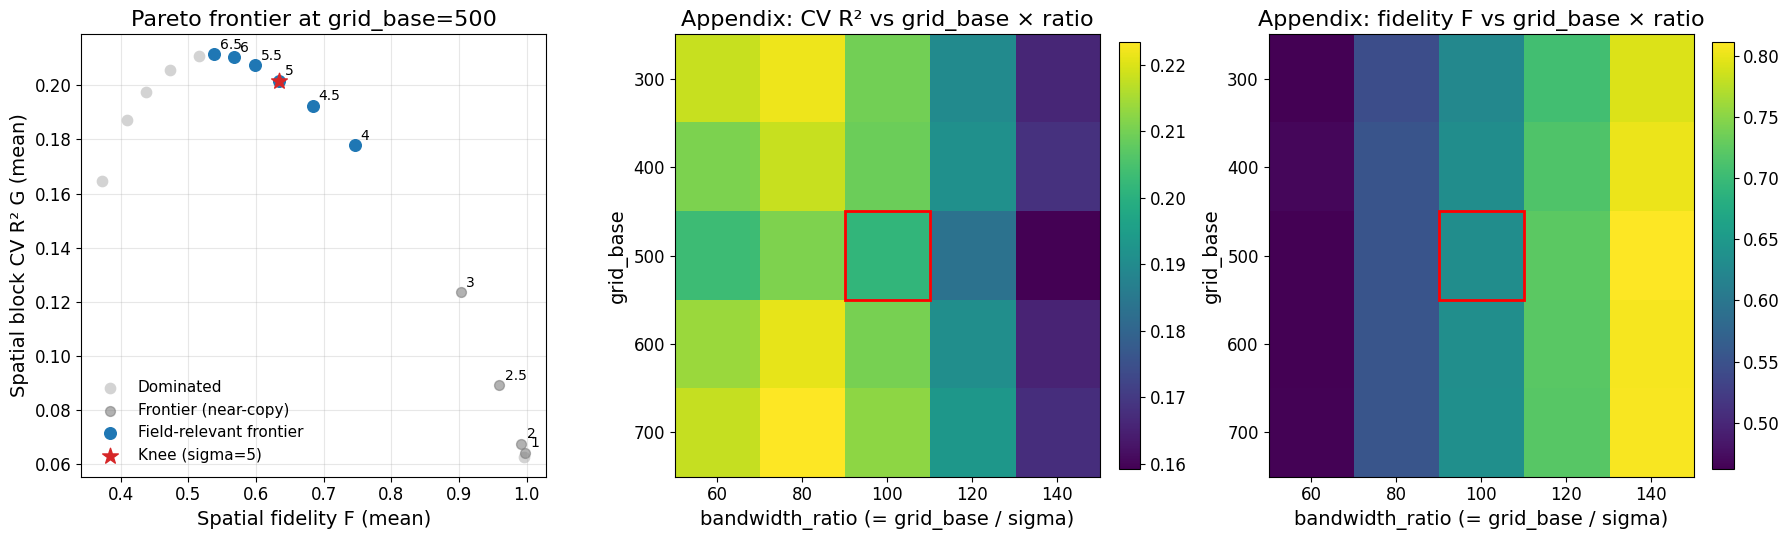

Equivalence grid: 5 ratios × 5 grid_base = 25 settings; canonical (500, ratio=100) ringed in red.


In [29]:
from pathlib import Path

# -------------------------
# 2C) Pareto frontier plot + equivalence heatmaps
# -------------------------
CANONICAL_BANDWIDTH_RATIO = int(round(RECOMMENDED_GRID_BASE / RECOMMENDED_SIGMA))

LABEL_SIZE = 14
TITLE_SIZE = 16
TICK_SIZE = 12
LEGEND_SIZE = 11
ANNOT_SIZE = 10

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

ax = axes[0]
ax.scatter(
    pareto_df.loc[~pareto_df["is_pareto"], "fidelity_mean"],
    pareto_df.loc[~pareto_df["is_pareto"], "cv_r2_mean"],
    c="lightgray",
    s=55,
    label="Dominated",
    zorder=1,
)
ax.scatter(
    pareto_frontier_df.loc[pareto_frontier_df["corr_mean"] > FIELD_RELEVANT_MAX_CORR, "fidelity_mean"],
    pareto_frontier_df.loc[pareto_frontier_df["corr_mean"] > FIELD_RELEVANT_MAX_CORR, "cv_r2_mean"],
    c="tab:gray",
    s=50,
    alpha=0.6,
    label="Frontier (near-copy)",
    zorder=1,
)
ax.scatter(
    pareto_knee_df["fidelity_mean"],
    pareto_knee_df["cv_r2_mean"],
    c="tab:blue",
    s=70,
    label="Field-relevant frontier",
    zorder=2,
)
ax.scatter(
    knee_row["fidelity_mean"],
    knee_row["cv_r2_mean"],
    c="tab:red",
    s=140,
    marker="*",
    label=f"Knee (sigma={RECOMMENDED_SIGMA:g})",
    zorder=3,
)
for _, r in pareto_frontier_df.iterrows():
    ax.annotate(f"{r['sigma']:g}", (r["fidelity_mean"], r["cv_r2_mean"]), textcoords="offset points", xytext=(4, 4), fontsize=ANNOT_SIZE)
ax.set_xlabel("Spatial fidelity F (mean)", fontsize=LABEL_SIZE)
ax.set_ylabel("Spatial block CV R² G (mean)", fontsize=LABEL_SIZE)
ax.set_title(f"Pareto frontier at grid_base={FOCUS_GRID_BASE}", fontsize=TITLE_SIZE)
ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left", frameon=False, fontsize=LEGEND_SIZE)


def _plot_equiv_heatmap(ax, value_col, title):
    mat = equiv_df.pivot(index="grid_base", columns="bandwidth_ratio", values=value_col)
    im = ax.imshow(mat.values, aspect="auto", cmap="viridis")
    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.set_xlabel("bandwidth_ratio (= grid_base / sigma)", fontsize=LABEL_SIZE)
    ax.set_ylabel("grid_base", fontsize=LABEL_SIZE)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels([str(int(c)) for c in mat.columns], fontsize=TICK_SIZE)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([str(int(i)) for i in mat.index], fontsize=TICK_SIZE)
    if RECOMMENDED_GRID_BASE in mat.index and CANONICAL_BANDWIDTH_RATIO in mat.columns:
        yi = list(mat.index).index(RECOMMENDED_GRID_BASE)
        xi = list(mat.columns).index(CANONICAL_BANDWIDTH_RATIO)
        ax.add_patch(plt.Rectangle((xi - 0.5, yi - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2))
    return im

im1 = _plot_equiv_heatmap(axes[1], "cv_r2_mean", "Appendix: CV R² vs grid_base × ratio")
cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.ax.tick_params(labelsize=TICK_SIZE)
im2 = _plot_equiv_heatmap(axes[2], "fidelity_mean", "Appendix: fidelity F vs grid_base × ratio")
cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cbar2.ax.tick_params(labelsize=TICK_SIZE)

plt.tight_layout()
FIG_DIR = Path("figure")
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "code_3_field_param_pareto.png", dpi=200, bbox_inches="tight")
plt.show()

print(
    f"Equivalence grid: {len(EQUIV_BANDWIDTH_RATIOS)} ratios × {len(EQUIV_GRID_BASE_CANDIDATES)} grid_base "
    f"= {len(equiv_df)} settings; canonical ({RECOMMENDED_GRID_BASE}, ratio={CANONICAL_BANDWIDTH_RATIO}) ringed in red."
)


<a id="sec-2-6-focus"></a>

### 2.6 Metrics vs sigma

Line plots of `fidelity_mean`, `cv_r2_mean`, and diagnostic in-sample `R²` versus `sigma` at `grid_base = 500`.


,grid_base,sigma,corr_mean,corr_std,fidelity_mean,fidelity_std,mae_mean,hotspot_overlap_mean,cv_r2_mean,cv_r2_std,r2_insample_mean,rmse_insample_mean,is_pareto,is_knee
0,500,1.0,0.999028,0.000715,0.997609,0.001106,0.010604,0.996190,0.064176,0.089652,0.205078,2.397102,True,False
1,500,1.5,0.998313,0.001237,0.996299,0.001979,0.015474,0.994286,0.062778,0.089799,0.204475,2.398029,False,False
2,500,2.0,0.997415,0.001373,0.991564,0.002287,0.082480,0.985714,0.067569,0.096793,0.215579,2.379049,True,False
3,500,2.5,0.987994,0.001018,0.959235,0.005659,0.353893,0.930476,0.089139,0.124305,0.258632,2.303907,True,False
4,500,3.0,0.952639,0.002055,0.902510,0.007757,0.766228,0.852381,0.123505,0.169931,0.326781,2.180163,True,False
5,500,4.0,0.828496,0.007971,0.745677,0.008534,1.487357,0.662857,0.177824,0.256191,0.444098,1.952061,True,False
6,500,4.5,0.770448,0.011731,0.683796,0.011056,1.737552,0.597143,0.192334,0.287634,0.482502,1.872920,True,False
7,500,5.0,0.722094,0.015763,0.633904,0.010419,1.938238,0.545714,0.201593,0.313964,0.512886,1.808672,True,True
8,500,5.5,0.682356,0.019932,0.598321,0.015546,2.106200,0.514286,0.207307,0.337077,0.538263,1.753838,True,False
9,500,6.0,0.649311,0.024174,0.567513,0.013774,2.251438,0.485714,0.210386,0.358040,0.560190,1.705515,True,False


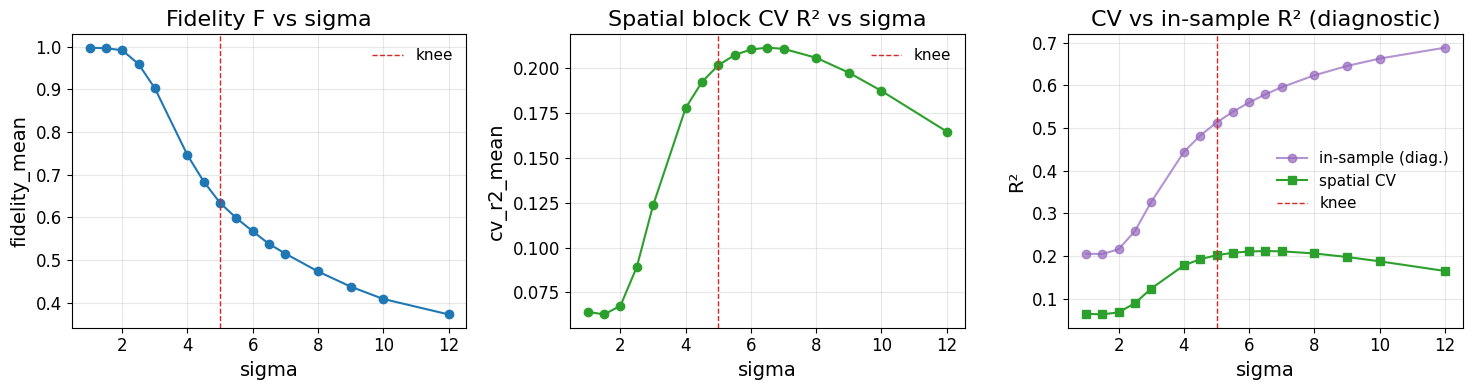

In [28]:
from pathlib import Path

# -------------------------
# 2D) Metrics vs sigma at grid_base = 500
# -------------------------
focus_df = pareto_df.sort_values("sigma").copy()
display(focus_df)

LABEL_SIZE = 14
TITLE_SIZE = 16
TICK_SIZE = 12
LEGEND_SIZE = 11

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(focus_df["sigma"], focus_df["fidelity_mean"], marker="o")
axes[0].axvline(RECOMMENDED_SIGMA, color="tab:red", ls="--", lw=1, label="knee")
axes[0].set_title("Fidelity F vs sigma", fontsize=TITLE_SIZE)
axes[0].set_xlabel("sigma", fontsize=LABEL_SIZE)
axes[0].set_ylabel("fidelity_mean", fontsize=LABEL_SIZE)
axes[0].tick_params(axis="both", labelsize=TICK_SIZE)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=False, fontsize=LEGEND_SIZE)

axes[1].plot(focus_df["sigma"], focus_df["cv_r2_mean"], marker="o", color="tab:green")
axes[1].axvline(RECOMMENDED_SIGMA, color="tab:red", ls="--", lw=1, label="knee")
axes[1].set_title("Spatial block CV R² vs sigma", fontsize=TITLE_SIZE)
axes[1].set_xlabel("sigma", fontsize=LABEL_SIZE)
axes[1].set_ylabel("cv_r2_mean", fontsize=LABEL_SIZE)
axes[1].tick_params(axis="both", labelsize=TICK_SIZE)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=False, fontsize=LEGEND_SIZE)

axes[2].plot(focus_df["sigma"], focus_df["r2_insample_mean"], marker="o", color="tab:purple", alpha=0.7, label="in-sample (diag.)")
axes[2].plot(focus_df["sigma"], focus_df["cv_r2_mean"], marker="s", color="tab:green", label="spatial CV")
axes[2].axvline(RECOMMENDED_SIGMA, color="tab:red", ls="--", lw=1, label="knee")
axes[2].set_title("CV vs in-sample R² (diagnostic)", fontsize=TITLE_SIZE)
axes[2].set_xlabel("sigma", fontsize=LABEL_SIZE)
axes[2].set_ylabel("R²", fontsize=LABEL_SIZE)
axes[2].tick_params(axis="both", labelsize=TICK_SIZE)
axes[2].grid(True, alpha=0.3)
axes[2].legend(frameon=False, fontsize=LEGEND_SIZE)

plt.tight_layout()
FIG_DIR = Path("figure")
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "code_3_field_param_sigma_curves.png", dpi=200, bbox_inches="tight")
plt.show()


<a id="sec-2-7-recommend"></a>

### 2.7 Knee selection and robustness

Report the Pareto knee `(grid_base, sigma)`, compare fidelity / CV-`R²` on neighbouring sigma values, and set `FX_BASE_SIGMA` when the knee matches the export default.


In [21]:
# -------------------------
# 2E) Knee recommendation + neighbour robustness
# -------------------------
print("Final recommended setting (Pareto knee):")
display(
    knee_row[
        [
            "grid_base",
            "sigma",
            "fidelity_mean",
            "cv_r2_mean",
            "corr_mean",
            "hotspot_overlap_mean",
            "r2_insample_mean",
        ]
    ].to_frame().T
)

# Neighbouring sigma values on the swept grid
sigmas = np.array(sorted(pareto_df["sigma"].unique()), dtype=float)
knee_idx = int(np.argmin(np.abs(sigmas - RECOMMENDED_SIGMA)))
neighbour_sigmas = sorted(set(sigmas[[max(0, knee_idx - 1), knee_idx, min(len(sigmas) - 1, knee_idx + 1)]]))
robust_df = pareto_df[pareto_df["sigma"].isin(neighbour_sigmas)].sort_values("sigma")
print("Neighbourhood robustness on swept sigma grid:")
display(robust_df[["sigma", "fidelity_mean", "cv_r2_mean", "corr_mean", "hotspot_overlap_mean"]])

if abs(RECOMMENDED_SIGMA - FX_BASE_SIGMA) < 1e-6 and RECOMMENDED_GRID_BASE == FX_BASE_GRID_BASE:
    print(f"Knee matches export defaults: grid_base={FX_BASE_GRID_BASE}, sigma={FX_BASE_SIGMA}")
else:
    print(
        f"Note: knee ({RECOMMENDED_GRID_BASE}, {RECOMMENDED_SIGMA:g}) differs from export defaults "
        f"({FX_BASE_GRID_BASE}, {FX_BASE_SIGMA}). Section 1.3 / 3.3 still use FX_BASE_* unless updated."
    )


Final recommended setting (Pareto knee):


,grid_base,sigma,fidelity_mean,cv_r2_mean,corr_mean,hotspot_overlap_mean,r2_insample_mean
2,500,5.0,0.633904,0.201593,0.722094,0.545714,0.512886


Neighbourhood robustness on swept sigma grid:


,sigma,fidelity_mean,cv_r2_mean,corr_mean,hotspot_overlap_mean
6,4.5,0.683796,0.192334,0.770448,0.597143
7,5.0,0.633904,0.201593,0.722094,0.545714
8,5.5,0.598321,0.207307,0.682356,0.514286


Knee matches export defaults: grid_base=500, sigma=5.0


<a id="sec-3-viz"></a>

## 3. Activity Comfort Field Visualization

This block compares grid-level **social activity comfort** (raw inputs) and the smoothed **activity comfort field** for each category, including map views and raw-vs-field scatter diagnostics.

**Subsections:**
- [3.1 Raw vs field maps](#sec-3-1-maps)
- [3.2 Feature maps](#sec-3-2-features)
- [3.3 Export modelling GPKG](#sec-3-3-export)


<a id="sec-3-1-maps"></a>

### 3.1 Raw vs field maps

Per-activity panels: choropleth of raw `social_activity_comfort_*`, smoothed `{key}_field`, and scatter of raw vs field values.


/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_40292/2392267335.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


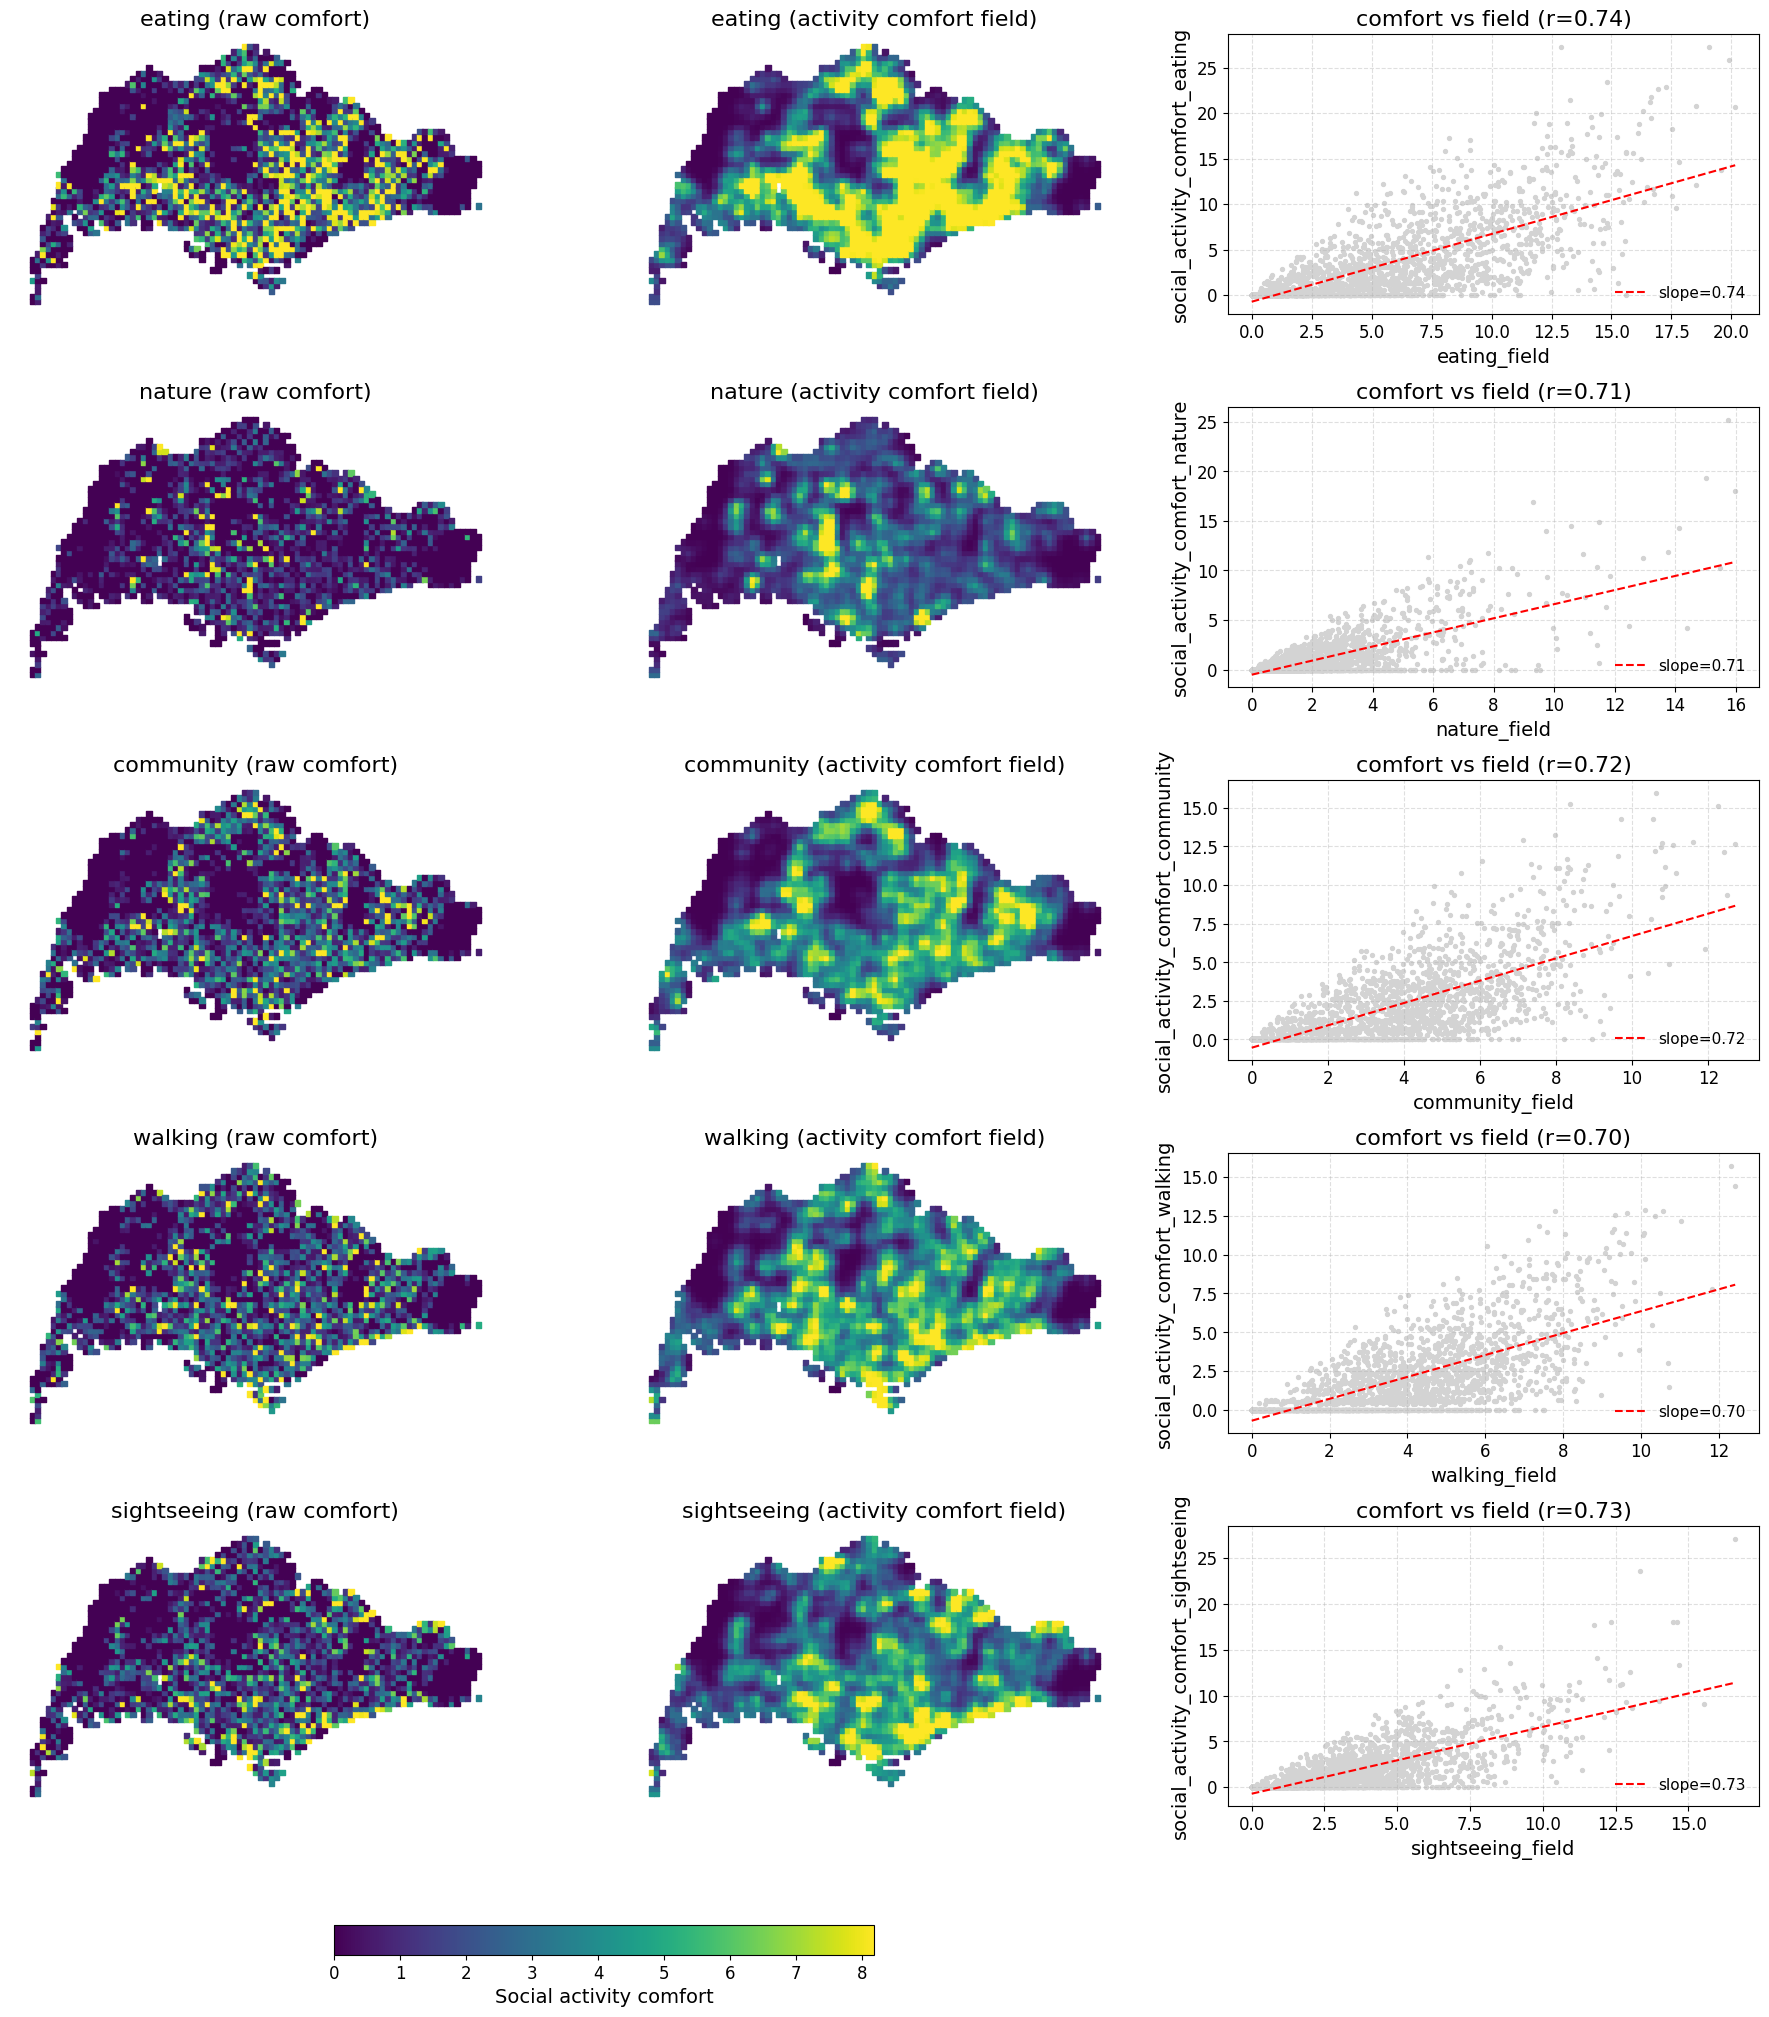

Social activity comfort (raw) and activity comfort field column list:
['social_activity_comfort_eating', 'social_activity_comfort_nature', 'social_activity_comfort_community', 'social_activity_comfort_walking', 'social_activity_comfort_sightseeing', 'eating_field', 'nature_field', 'community_field', 'walking_field', 'sightseeing_field']
===== Raw social activity comfort (value description) =====
social_activity_comfort_eating (raw comfort) describe():
count    2096.000000
mean        3.012125
std         4.139941
min         0.000000
25%         0.000000
50%         1.306972
75%         4.469070
max        27.280223
Name: social_activity_comfort_eating, dtype: float64
social_activity_comfort_nature (raw comfort) describe():
count    2096.000000
mean        1.070498
std         2.040865
min         0.000000
25%         0.000000
50%         0.000000
75%         1.321005
max        25.181582
Name: social_activity_comfort_nature, dtype: float64
social_activity_comfort_community (raw comfor

In [27]:
# -------------------------
# 3A) Activity comfort field: raw social activity comfort vs smoothed field
# -------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl

if "fx_df" not in globals():
    raise RuntimeError("Please run the activity comfort field extraction block first.")

missing_field = [k for k in FX_ACT_KEYS if f"{k}_field" not in fx_df.columns]
if missing_field:
    raise RuntimeError(f"Missing field columns: {missing_field}. Re-run the activity comfort field block.")

LABEL_SIZE = 14
TITLE_SIZE = 16
TICK_SIZE = 12
LEGEND_SIZE = 11
CBAR_LABEL_SIZE = 14

n_acts = len(FX_ACT_KEYS)
fig, axes = plt.subplots(n_acts, 3, figsize=(18, 4 * n_acts))
if n_acts == 1:
    axes = np.array([axes])

# Shared color scale for raw comfort vs activity comfort field maps
all_vals = []
for src, k in zip(FX_COMFORT_SOURCE_COLS, FX_ACT_KEYS):
    all_vals.extend(fx_df[src].values.tolist())
    all_vals.extend(fx_df[f"{k}_field"].values.tolist())
vmin = float(np.nanmin(all_vals))
vmax = float(np.nanmax(all_vals)) * 0.3 # Set a cap for clear visualisation

for r, (k, src) in enumerate(zip(FX_ACT_KEYS, FX_COMFORT_SOURCE_COLS)):
    raw_col = src
    sm_col = f"{k}_field"

    ax_raw, ax_smooth, ax_scatter = axes[r, 0], axes[r, 1], axes[r, 2]

    fx_df.plot(
        ax=ax_raw,
        column=raw_col,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        marker="s",
        markersize=15,
        legend=False,
    )
    ax_raw.set_title(f"{k} (raw comfort)", fontsize=TITLE_SIZE)
    ax_raw.set_axis_off()

    fx_df.plot(
        ax=ax_smooth,
        column=sm_col,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        marker="s",
        markersize=15,
        legend=False,
    )
    ax_smooth.set_title(f"{k} (activity comfort field)", fontsize=TITLE_SIZE)
    ax_smooth.set_axis_off()

    x = fx_df[sm_col].values
    y = fx_df[raw_col].values
    ax_scatter.scatter(x, y, color="lightgrey", s=8)
    b, a = np.polyfit(x, y, 1)
    xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax_scatter.plot(xx, a + b * xx, "r--", linewidth=1.5, label=f"slope={b:.2f}")
    corr = np.corrcoef(x, y)[0, 1]
    ax_scatter.set_title(f"comfort vs field (r={corr:.2f})", fontsize=TITLE_SIZE)
    ax_scatter.set_xlabel(f"{k}_field", fontsize=LABEL_SIZE)
    ax_scatter.set_ylabel(src, fontsize=LABEL_SIZE)
    ax_scatter.tick_params(axis="both", labelsize=TICK_SIZE)
    ax_scatter.grid(True, linestyle="--", alpha=0.4)
    ax_scatter.legend(loc="lower right", frameon=False, fontsize=LEGEND_SIZE)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# Put colorbar at the very bottom to avoid overlap with scatter panels
fig.subplots_adjust(bottom=0.08)
cbar_ax = fig.add_axes([0.2, 0.02, 0.3, 0.015])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Social activity comfort", fontsize=CBAR_LABEL_SIZE)
cbar.ax.tick_params(labelsize=TICK_SIZE)

plt.tight_layout(rect=[0, 0.06, 1, 1])
from pathlib import Path
FIG_DIR = Path("figure")
PAPER_FIG_DIR = Path("paper/fig")
FIG_DIR.mkdir(parents=True, exist_ok=True)
PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "code_3_activity_comfort_field_raw_vs_smoothed.png", dpi=200, bbox_inches="tight")
plt.show()

print("Social activity comfort (raw) and activity comfort field column list:")
print(FX_COMFORT_SOURCE_COLS + [f"{k}_field" for k in FX_ACT_KEYS])

# Print value descriptions for raw and extracted data
print("===== Raw social activity comfort (value description) =====")
for src in FX_COMFORT_SOURCE_COLS:
    print(f"{src} (raw comfort) describe():")
    print(fx_df[src].describe())

print("===== Activity comfort field (value description) =====")
for k in FX_ACT_KEYS:
    print(f"{k}_field describe():")
    print(fx_df[f'{k}_field'].describe())



<a id="sec-3-2-features"></a>

### 3.2 Feature maps

Multi-panel choropleths for all geospatial features in `fx_available_features` on the merged grid.


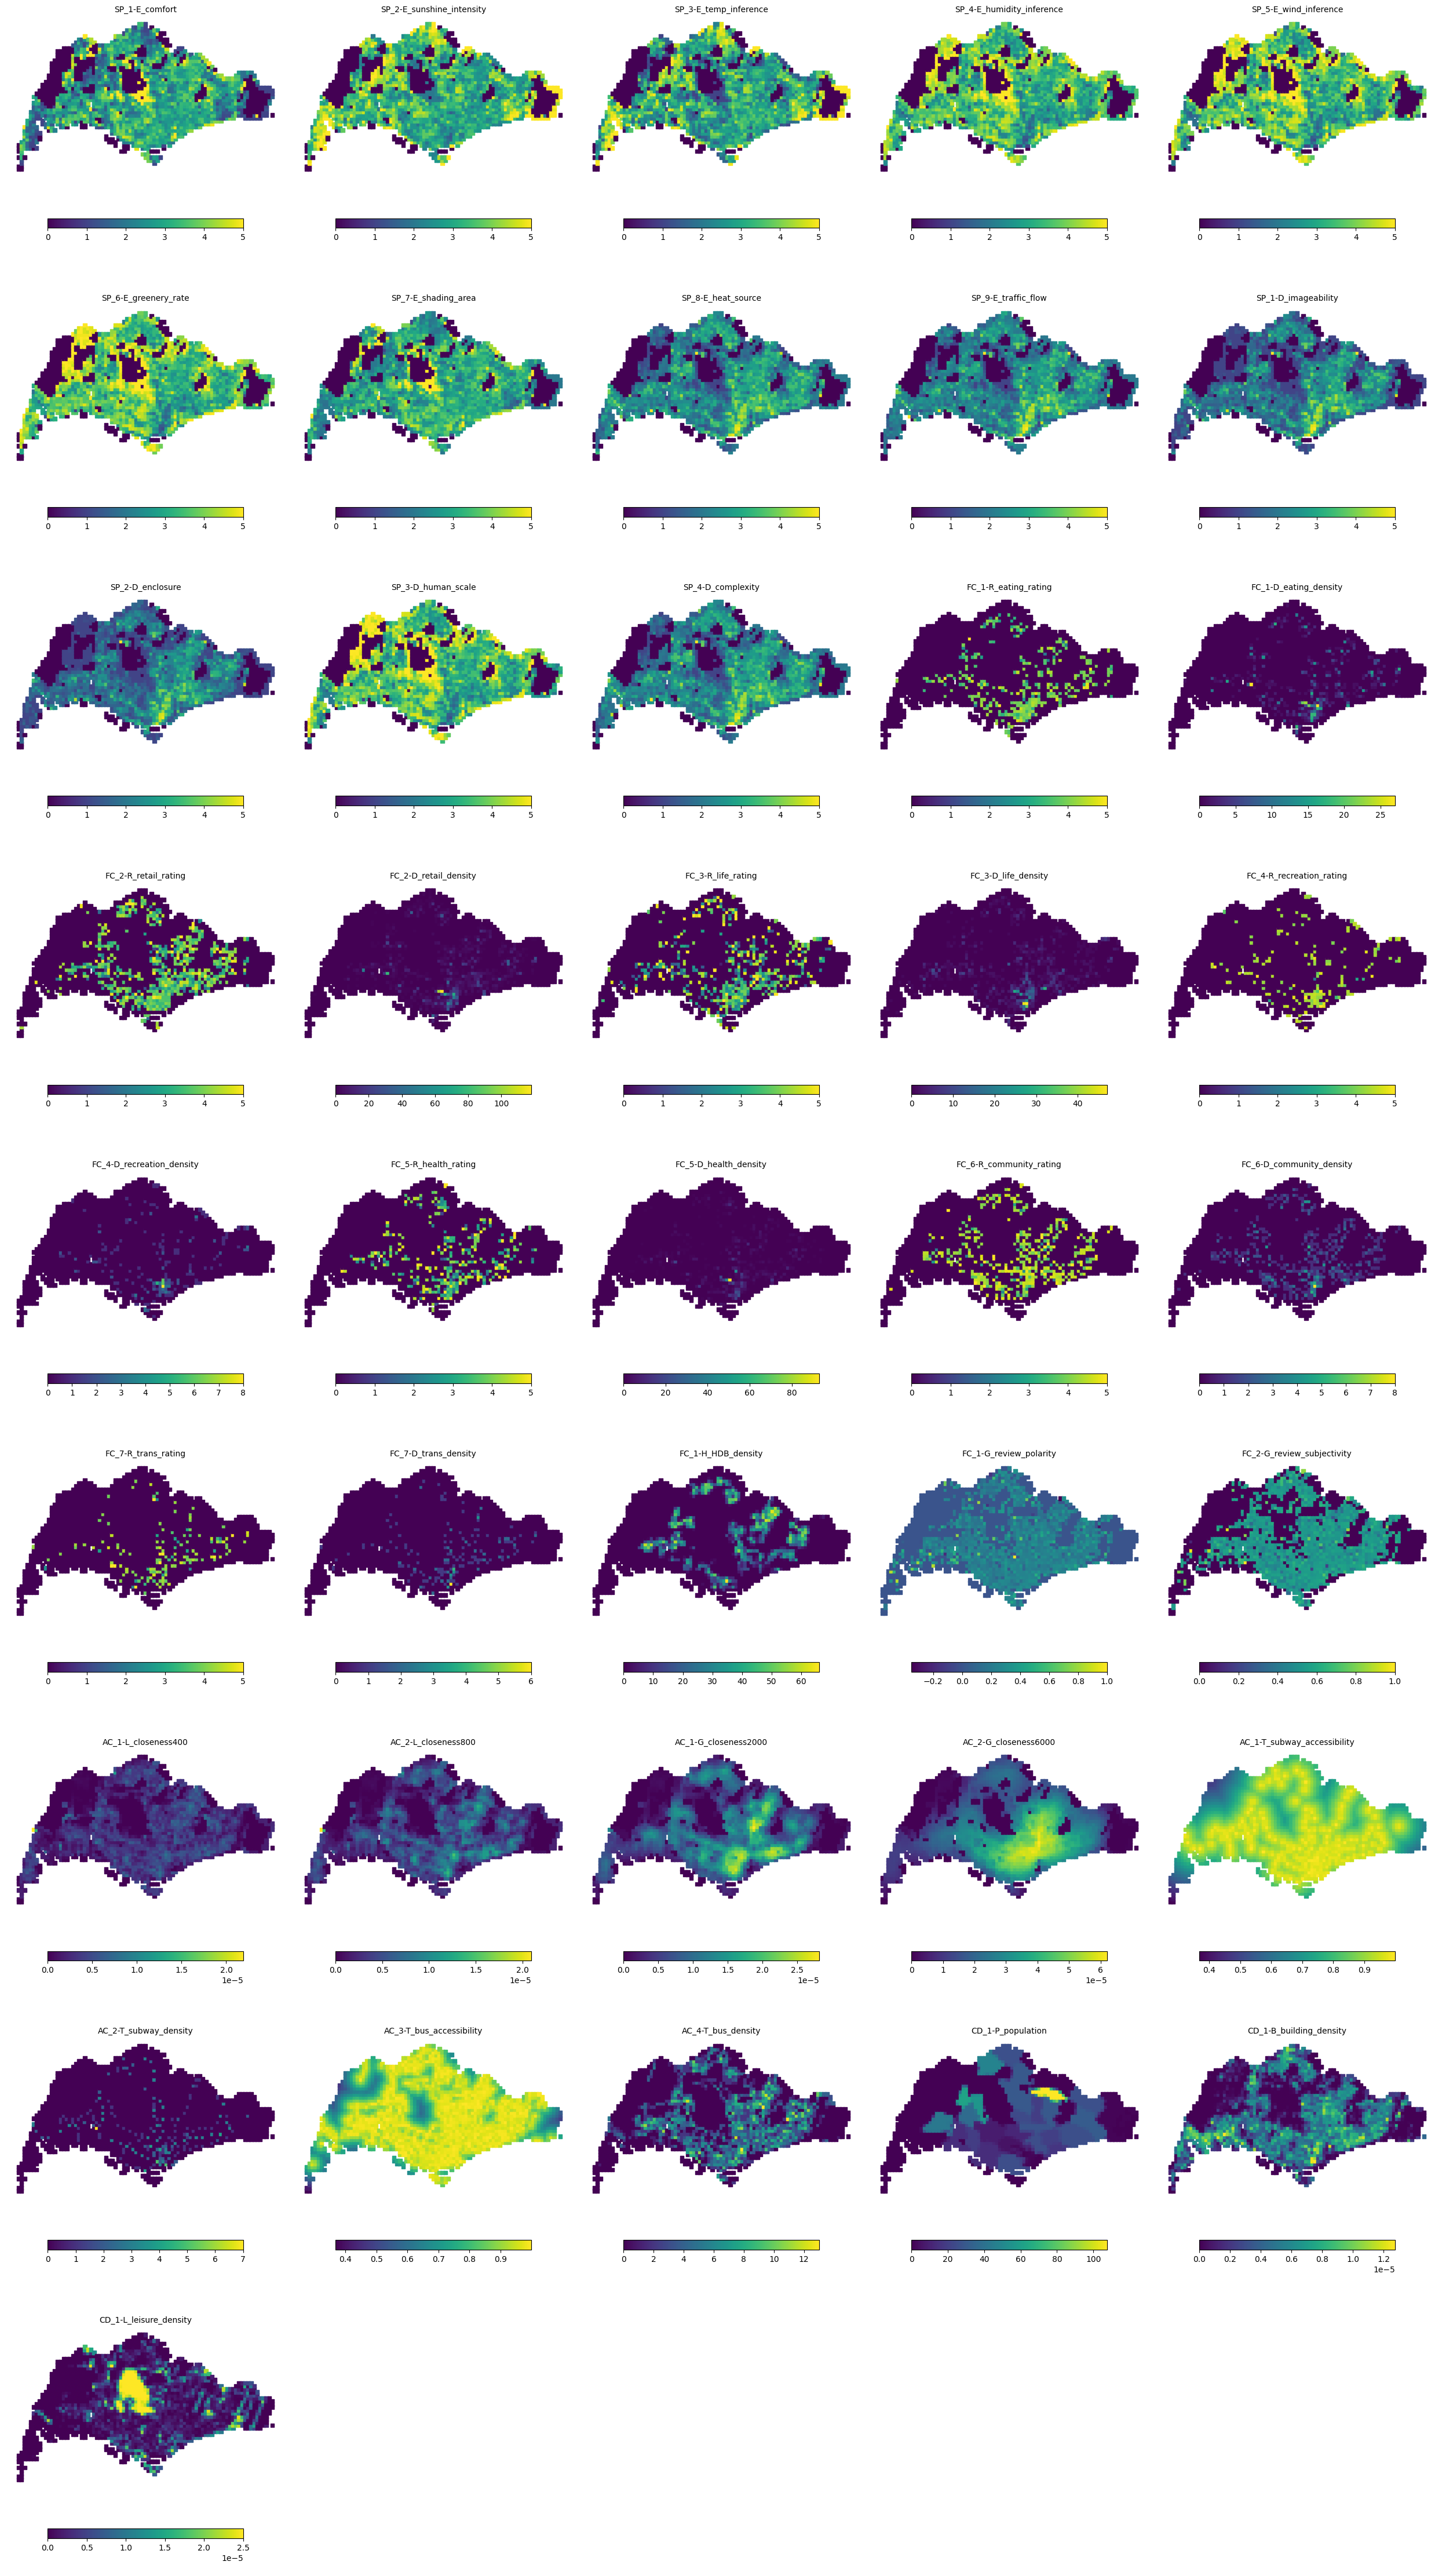

Visualized features: 41


In [10]:
# -------------------------
# 3B) Feature visualization (all features, single-pass)
# -------------------------

if "fx_df" not in globals():
    raise RuntimeError("Please run the activity comfort field extraction block first.")

feature_cols = [c for c in fx_available_features if c in fx_df.columns]
if not feature_cols:
    raise RuntimeError("No feature columns found for visualization.")

n_cols = 5
n_rows = int(len(feature_cols) / n_cols) + (len(feature_cols) % n_cols > 0)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

for i, col in enumerate(feature_cols):
    ax = axes.flat[i]
    fx_df.plot(
        ax=ax,
        column=col,
        marker="s",
        markersize=22,
        legend=True,
        cmap="viridis",
        legend_kwds={"orientation": "horizontal", "shrink": 0.7},
    )
    ax.set_title(col, fontsize=10)
    ax.axis("off")

for j in range(i + 1, n_rows * n_cols):
    axes.flat[j].axis("off")

plt.tight_layout()
plt.show()

print(f"Visualized features: {len(feature_cols)}")


<a id="sec-3-3-export"></a>

### 3.3 Export modelling GPKG

Write `data/data_uci_modelling.gpkg` with `id`, coordinates, `{key}_field`, original feature columns, and geometry for downstream UCI notebooks.


In [11]:
# -------------------------
# 3C) Export activity comfort field + original features to GPKG
# -------------------------
from pathlib import Path

FX_EXPORT_DIR = Path("data")
FX_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FX_EXPORT_GPKG = FX_EXPORT_DIR / "data_uci_modelling.gpkg"

field_cols = [f"{k}_field" for k in FX_ACT_KEYS if f"{k}_field" in fx_gdf.columns]
feature_cols = [f for f in fx_available_features if f in fx_gdf.columns]

fx_export_cols = ["id", "longitude", "latitude"] + field_cols + feature_cols + ["geometry"]
fx_export_cols = [c for c in fx_export_cols if c in fx_gdf.columns]

if len(field_cols) == 0 or len(feature_cols) == 0:
    raise RuntimeError("Missing activity comfort field columns or feature columns. Please run the extraction cells first.")

fx_export_gdf = fx_gdf[fx_export_cols].copy()
fx_export_gdf.to_file(FX_EXPORT_GPKG, driver="GPKG")

print(f"Exported: {FX_EXPORT_GPKG}")
print(f"Rows: {len(fx_export_gdf)}, Columns: {len(fx_export_gdf.columns)}")
print(f"Features: {len(feature_cols)}, Activity comfort fields: {len(field_cols)}")
print("Exported columns:")
for col in fx_export_cols:
    print(f"  {col}")


Exported: data/data_uci_modelling.gpkg
Rows: 2096, Columns: 50
Features: 41, Activity comfort fields: 5
Exported columns:
  id
  longitude
  latitude
  eating_field
  nature_field
  community_field
  walking_field
  sightseeing_field
  SP_1-E_comfort
  SP_2-E_sunshine_intensity
  SP_3-E_temp_inference
  SP_4-E_humidity_inference
  SP_5-E_wind_inference
  SP_6-E_greenery_rate
  SP_7-E_shading_area
  SP_8-E_heat_source
  SP_9-E_traffic_flow
  SP_1-D_imageability
  SP_2-D_enclosure
  SP_3-D_human_scale
  SP_4-D_complexity
  FC_1-R_eating_rating
  FC_1-D_eating_density
  FC_2-R_retail_rating
  FC_2-D_retail_density
  FC_3-R_life_rating
  FC_3-D_life_density
  FC_4-R_recreation_rating
  FC_4-D_recreation_density
  FC_5-R_health_rating
  FC_5-D_health_density
  FC_6-R_community_rating
  FC_6-D_community_density
  FC_7-R_trans_rating
  FC_7-D_trans_density
  FC_1-H_HDB_density
  FC_1-G_review_polarity
  FC_2-G_review_subjectivity
  AC_1-L_closeness400
  AC_2-L_closeness800
  AC_1-G_closeness2

<a id="sec-4-handover"></a>

## 4. Handover

Unified modelling layer for [code_4](code_4_uci_causal_forest.ipynb) and [code_6](code_6_uci_modelling.ipynb): align on `id`, use `{key}_field` as activity-specific outcomes, keep geospatial features at original values.

**Subsections:**
- [4.1 Schema summary](#sec-4-1-schema)


<a id="sec-4-1-schema"></a>

### 4.1 Schema summary for downstream notebooks

After §3.3, `data/data_uci_modelling.gpkg` contains:

| Field group | Columns | Role |
|-------------|---------|------|
| Index | `id` | Join key across pipeline |
| Coordinates | `longitude`, `latitude`, `geometry` | Grid location (EPSG:4326) |
| Social activity comfort (inputs) | `social_activity_comfort_*` (in source GPKG only) | Raw grid comfort from [code_1](code_1_social_activity_data.ipynb) |
| Activity comfort fields (outputs) | `eating_field`, `nature_field`, `community_field`, `walking_field`, `sightseeing_field` | Smoothed exposure surfaces (`ACT_COLUMNS` in later notebooks) |
| Geospatial features | `SP_*`, `FC_*`, `AC_*`, `CD_*` | Original values from [code_2](code_2_geospatial_data.ipynb) |

Primary handover from the original notebook overview:
- Index for the location: `id`
- Social activity comfort columns **read from** `data_social_activity.gpkg`: `social_activity_comfort_eating`, …, `social_activity_comfort_sightseeing`
- Activity comfort field columns **saved to** `data_uci_modelling.gpkg`: short `{key}_field` names aligned with `ACT_COLUMNS`
- Geospatial feature columns unchanged; coordinates `longitude`, `latitude`; geometry `geometry`
